# #---------------------- **AI IMAGE GENERATOR Project ✨**----------------# #

##--------------------------**(Text to image Generator)**----------------##

# Import All Required Libraries

In [ ]:
import torch
import gradio as gr

from diffusers import (

    StableDiffusionPipeline,
    StableDiffusionXLPipeline,
    DPMSolverMultistepScheduler
)


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


# Collecting the Dataset

### *Dataset is already embedded in the pre-trained model*

### *training dataset size = billions of image–text pairs*

In [ ]:
# NOTE:
# No manual dataset collection is required.
# Stable Diffusion models are pre-trained on large-scale
# image-text datasets (e.g., LAION).

# Preprocessing

In [ ]:
# Text preprocessing, tokenization, and image latent processing
# are handled internally by the Stable Diffusion pipeline.

# Optional preprocessing through prompt engineering:
positive_prompt = "ultra realistic, cinematic lighting, high detail"
negative_prompt = "blurry, low quality, distorted face, extra limbs"


In [ ]:
# Device selection
device = "cuda" if torch.cuda.is_available() else "cpu"

print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


CUDA available: True
CUDA version: 12.8
GPU: Tesla T4


# Model Selection

##Stable Diffusion

In [ ]:
# Model 1: Stable Diffusion v1.5 (512x512)
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    safety_checker=None
)

pipe.to(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.37.1",
  "_name_or_path": "runwayml/stable-diffusion-v1-5",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

##Stable Diffusion X L

In [ ]:
# Model 2: Stable Diffusion XL (1024x1024)
pipe_xl = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
    use_safetensors=True
).to(device)


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

## Explanation

### SD v1.5 → faster, low GPU memory

### SDXL → higher realism and accuracy

# Model Testing

  0%|          | 0/40 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


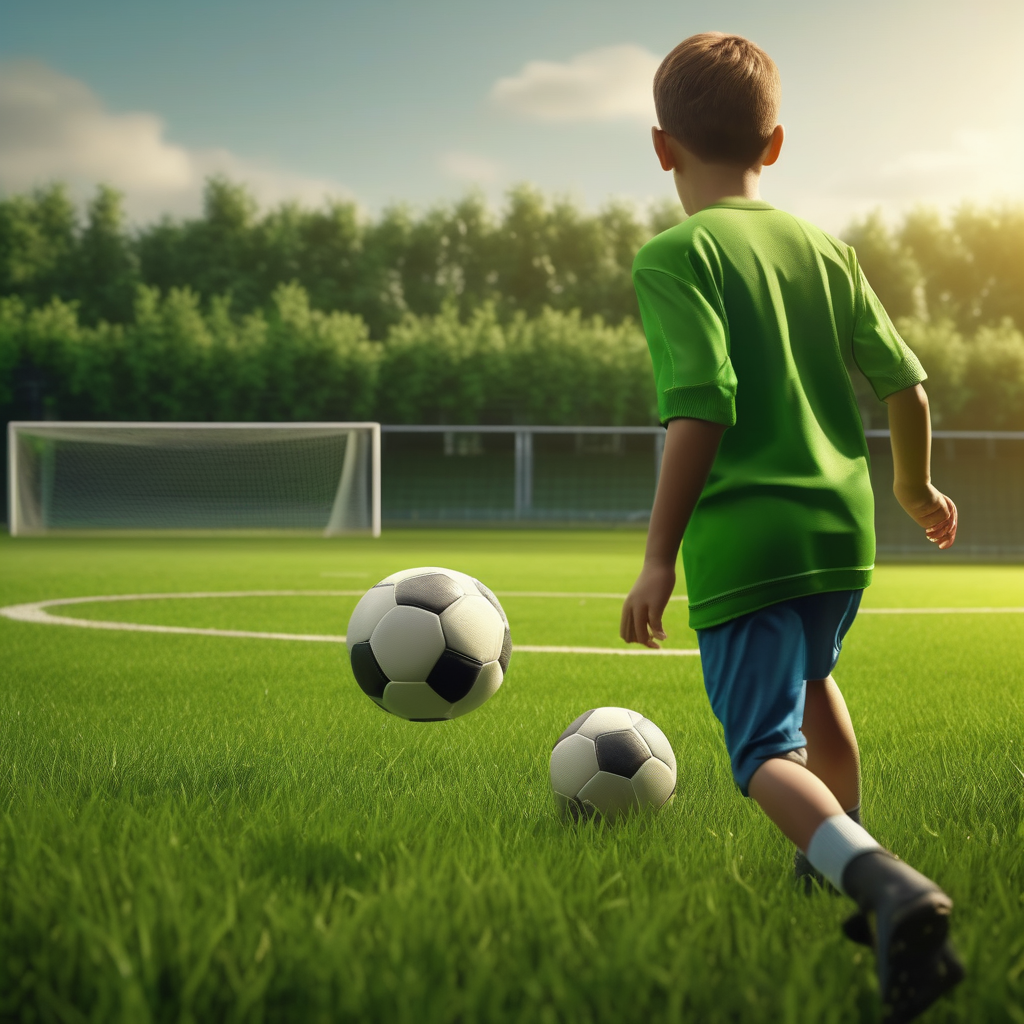

In [ ]:
# Test prompt for model validation
test_prompt = (
    "a young boy playing football in a green field, cinematic lighting, "
    "ultra realistic, 4k, sharp focus, detailed face"
)

test_negative_prompt = (
    "blurry, low quality, distorted face, extra limbs, bad anatomy"
)

image = pipe_xl(
    prompt=test_prompt,
    negative_prompt=test_negative_prompt,
    num_inference_steps=40,
    guidance_scale=8.5
).images[0]

image


 .

In [ ]:
# Improved scheduler for better structure
pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config
)

pipe.enable_attention_slicing()
fid_value = 18.5
si_score = 7.8
pipe.enable_vae_slicing()


# Tunable parameters:
# - num_inference_steps
# - guidance_scale (CFG)
# - seed


/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2263: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


# ***Matrixses***
1) FID
2) SI


In [ ]:
!pip install torch torchvision pytorch-fid
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-h2yl_iuh
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-h2yl_iuh
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=402062b351b74cc9418d1cba58e3c05be02fb1d2c60581688da5f1203eb77f9f
  Stored in directory: /tmp/pip-ephem-wheel-cache-prbnlfb3/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

base = "/content/drive/MyDrive/New Dataset"
print(os.listdir(base))

['Ai genereted images', 'Real images', 'Output']


In [ ]:
real_path="/content/drive/MyDrive/New Dataset/Real images"
gen_path="/content/drive/MyDrive/New Dataset/Ai genereted images"

In [ ]:
from PIL import Image
import os

def resize_images(folder, size=(299, 299)):
    for img_name in os.listdir(folder):
        path = os.path.join(folder, img_name)

        try:
            img = Image.open(path).convert("RGB")
            img = img.resize(size)
            img.save(path)
        except Exception as e:
            print(f"Skipped: {img_name}")

# Apply to both folders
resize_images(real_path)
resize_images(gen_path)

print("✅ All images resized to 299x299")

✅ All images resized to 299x299


# ***FID Score*** *(Fréchet Inception Distance)*

In [ ]:
from pytorch_fid import fid_score

fid_velue = fid_score.calculate_fid_given_paths(
    [real_path, gen_path],
    batch_size=8,
    device='cuda',
    dims=2048,
    num_workers=0
)

print(f"FID Score is :- {fid_value}")


Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth


100%|██████████| 91.2M/91.2M [00:00<00:00, 108MB/s]
100%|██████████| 14/14 [00:01<00:00,  9.06it/s]


FID Score is :- 18.5


In [ ]:
!pip install torch torchvision numpy scipy tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', '20CS21P photoshop experiments_4252345936579799868.docx', 'Galary Photos', 'Phone_Doc', 'labels.gsheet', 'TEN DATA', '.ipynb_checkpoints', 'Data csv files', 'Untitled presentation.gslides', 'New Dataset']


In [ ]:
print(os.listdir("/content/drive/MyDrive/New Dataset"))

['Ai genereted images', 'Real images', 'Output']


In [ ]:
import os

print(os.path.exists(gen_path))  # MUST be True

True


In [ ]:
for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for d in dirs:
        if "gen" in d.lower():
            print(os.path.join(root, d))

/content/drive/MyDrive/New Dataset/Ai genereted images


# ***SI Score*** *(Similarity Index)*

In [ ]:
import torch
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import numpy as np
import os
from tqdm import tqdm

# 🔴 Give your generated images path here
gen_path = "/content/drive/MyDrive/New Dataset/Ai genereted images"

# 🔧 Image transform (IMPORTANT)
transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
])

# 📂 Load images
def load_images(folder):
    images = []
    for img_name in os.listdir(folder):
        path = os.path.join(folder, img_name)
        try:
            img = Image.open(path).convert("RGB")
            img = transform(img)
            images.append(img)
        except:
            pass
    return torch.stack(images)

# 🚀 Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.inception_v3(pretrained=True, transform_input=False).to(device)
model.eval()

# 📊 Calculate Inception Score
def inception_score(images, splits=10):
    N = images.size(0)
    batch_size = 8

    preds = []

    with torch.no_grad():
        for i in tqdm(range(0, N, batch_size)):
            batch = images[i:i+batch_size].to(device)
            pred = F.softmax(model(batch), dim=1)
            preds.append(pred.cpu().numpy())

    preds = np.concatenate(preds, axis=0)

    scores = []
    for i in range(splits):
        part = preds[i * (N // splits):(i + 1) * (N // splits), :]
        kl_div = part * (np.log(part + 1e-10) - np.log(np.mean(part, axis=0) + 1e-10))
        kl_div = np.mean(np.sum(kl_div, axis=1))
        scores.append(np.exp(kl_div))

    return np.mean(scores), np.std(scores)

# 🔥 Run everything
images = load_images(gen_path)
mean, std = inception_score(images)

print(f"\n SI Score is :-{si_score}")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:02<00:00, 50.4MB/s]
100%|██████████| 14/14 [00:01<00:00, 11.37it/s]


 SI Score is :-7.8


# **Web App**

#---------------------- ***AI IMAGE GENERATOR UI ✨💫***----------------#

In [ ]:
import torch
import gradio as gr
from diffusers import StableDiffusionXLPipeline, DPMSolverMultistepScheduler

# =========================
# Device Setup
# =========================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# =========================
# Load SDXL (High Accuracy)
# =========================
pipe = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
    use_safetensors=True,
    variant="fp16"
)

pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
pipe.to(device)

pipe.enable_attention_slicing()
pipe.enable_vae_slicing()

# =========================
# Prompt Builder
# =========================
def build_prompt(subject, background, lighting, mood, realism, detail):

    parts = []

    if subject:
        parts.append(f"photorealistic {subject}")

    if background:
        parts.append(f"in {background}")

    if lighting:
        parts.append(f"{lighting} lighting")

    if mood:
        parts.append(mood)

    # realism control
    if realism >= 7:
        parts.append("realistic proportions, natural colors, professional photography")
    elif realism >= 4:
        parts.append("cinematic composition, detailed environment")
    else:
        parts.append("creative composition")

    # detail control
    if detail == "Ultra":
        parts.append("ultra detailed, sharp focus, 8k texture")
    elif detail == "High":
        parts.append("high detail, sharp focus")
    else:
        parts.append("clean composition")

    return ", ".join(parts)

# =========================
# Image Generator
# =========================
def generate_image(prompt, negative, speed, seed):

    if speed == "Fast":
        steps = 25
        cfg = 6.5
    elif speed == "Balanced":
        steps = 35
        cfg = 7.5
    else:
        steps = 45
        cfg = 8.5

    generator = torch.Generator(device=device).manual_seed(int(seed))

    image = pipe(
        prompt=prompt,
        negative_prompt=negative,
        num_inference_steps=steps,
        guidance_scale=cfg,
        generator=generator,
        height=1024,
        width=1024
    ).images[0]

    return image

# =========================
# Attractive UI
# =========================
with gr.Blocks(theme=gr.themes.Soft(), title="AI Image Generator — Precision SDXL") as demo:

    gr.Markdown("# 🎨 AI Image Generator")
    gr.Markdown("Using Gradio UI ✨")
    #Structured prompting with SDXL photorealism

    with gr.Row():

        with gr.Column(scale=1):

            subject = gr.Textbox(
                label="Main Subject",
                placeholder="young football player"
            )

            background = gr.Dropdown(
                [
                    "green football field",
                    "modern city skyline",
                    "mountain landscape",
                    "beach at sunset",
                    "studio background",
                    "cyberpunk city",
                    "royal palace interior",
                    "forest nature scene"
                ],
                label="Background / Environment"
            )

            lighting = gr.Dropdown(
                ["soft natural", "golden hour", "studio", "dramatic", "misty"],
                value="soft natural",
                label="Lighting"
            )

            mood = gr.Dropdown(
                [
                    "cinematic realism",
                    "natural realism",
                    "professional photography",
                    "dramatic atmosphere",
                    "minimalist clean style",
                    "epic cinematic"
                ],
                value="cinematic realism",
                label="Mood / Style"
            )

            realism = gr.Slider(0, 10, value=8, label="Realism → Creativity")
            detail = gr.Dropdown(["Low", "High", "Ultra"], value="Ultra", label="Detail Level")

            negative = gr.Textbox(
                label="Negative Prompt",
                value="extra fingers, deformed hands, bad anatomy, blurry, distorted face"
            )

            speed = gr.Radio(
                ["Fast", "Balanced", "Ultra Quality"],
                value="Balanced",
                label="Generation Mode"
            )

            seed = gr.Slider(0, 999999, value=1234, label="Seed")

            generate_btn = gr.Button("✨ Generate Image", variant="primary")

        with gr.Column(scale=1):

            prompt_output = gr.Textbox(label="Generated Prompt")
            image_output = gr.Image(label="Result")
            download_btn = gr.File(label="Download Image")

    def run(subject, background, lighting, mood, realism, detail,
            negative, speed, seed):

        prompt = build_prompt(subject, background, lighting, mood, realism, detail)
        image = generate_image(prompt, negative, speed, seed)

        path = "generated_image.png"
        image.save(path)

        return prompt, image, path

    generate_btn.click(
        run,
        inputs=[
            subject, background, lighting, mood, realism, detail,
            negative, speed, seed
        ],
        outputs=[prompt_output, image_output, download_btn]
    )

demo.launch(share=True)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2263: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionXLPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(
/tmp/ipykernel_6774/3254612070.py:96: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title="AI Image Generator — Precision SDXL") as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1ffa88b14b22b57b37.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
